# Perbandingan Metode Imputasi Missing Value terhadap Kinerja Model Klasifikasi Pada Dataset Diabetes

---

| Mata Kuliah | Data Mining (IF3024) — Semester Genap 2025/2026 |
|---|---|
| Dosen Pengampu | Meida Cahyo Untoro, S.Kom., M.Kom.|
| Kelompok | 05 |
| Topik | Missing Value |

### Anggota Kelompok

| No | NIM | Nama Lengkap |
|----|-----|-------------|
| 1 | 123140078| Najlatika|
| 2 | 123140089|Bening Apni Prameswari|
| 3 | 123140124| Falent Antonius Panjaitan |
| 4 | 123140125| Raditya Alrasyid Nugroho |
| 5 | 123140169| Raisya Syifa Saleh |
| 6 | 123140186| Muhamad Arif Ardani |

In [ ]:
# =================
# IMPORT LIBRARY
# =================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

# =========================
# 3.3 PROSEDUR EKSPERIMEN
# =========================

# 1. Split Feature dan Target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# 2. Split Train & Test (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. List Metode Imputasi untuk Dibandingkan (Mean, KNN, MICE)
imputers = {
    'Mean': SimpleImputer(strategy='mean'),
    'KNN': KNNImputer(n_neighbors=5),
    'MICE': IterativeImputer(max_iter=20, random_state=42)
}

results = []

# 4. Loop Perbandingan
for name, imputer in imputers.items():
    # Proses Imputasi
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # Model Random Forest
    clf = RandomForestClassifier(random_state=42)
    clf.fit(X_train_imp, y_train)

    # Evaluasi
    y_pred = clf.predict(X_test_imp)

    results.append({
        'Metode': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred)
    })

# Tampilkan Hasil Akhir
df_hasil = pd.DataFrame(results)
print("\n===== HASIL PERBANDINGAN BAB 3 =====")
display(df_hasil)



===== HASIL PERBANDINGAN BAB 3 =====


,Metode,Accuracy,F1-Score,Recall
0,Mean,0.75974,0.633663,0.592593
1,KNN,0.75974,0.633663,0.592593
2,MICE,0.75974,0.633663,0.592593


In [ ]:
# ==============================
# LOAD DATA + INFO DASAR
# ==============================

# Link dataset Pima Indians Diabetes (Raw GitHub)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Nama-nama kolom sesuai deskripsi dataset di Kaggle
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load data langsung dari URL
df = pd.read_csv(url, names=column_names)

# Identifikasi Missing Value Tersembunyi (Nilai 0 diubah jadi NaN)
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)

print("===== HEAD =====")
display(df.head())

print("\n===== INFO =====")
df.info()

print("\n===== DESCRIBE (Setelah Replace 0 ke NaN) =====")
display(df.describe())

print("\n===== MISSING VALUE TERDETEKSI =====")
display(df.isnull().sum())

===== HEAD =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1



===== INFO =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   763 non-null    float64
 2   BloodPressure             733 non-null    float64
 3   SkinThickness             541 non-null    float64
 4   Insulin                   394 non-null    float64
 5   BMI                       757 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(6), int64(3)
memory usage: 54.1 KB

===== DESCRIBE (Setelah Replace 0 ke NaN) =====


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,763.000000,733.000000,541.000000,394.000000,757.000000,768.000000,768.000000,768.000000
mean,3.845052,121.686763,72.405184,29.153420,155.548223,32.457464,0.471876,33.240885,0.348958
std,3.369578,30.535641,12.382158,10.476982,118.775855,6.924988,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,64.000000,22.000000,76.250000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,141.000000,80.000000,36.000000,190.000000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000



===== MISSING VALUE TERDETEKSI =====


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


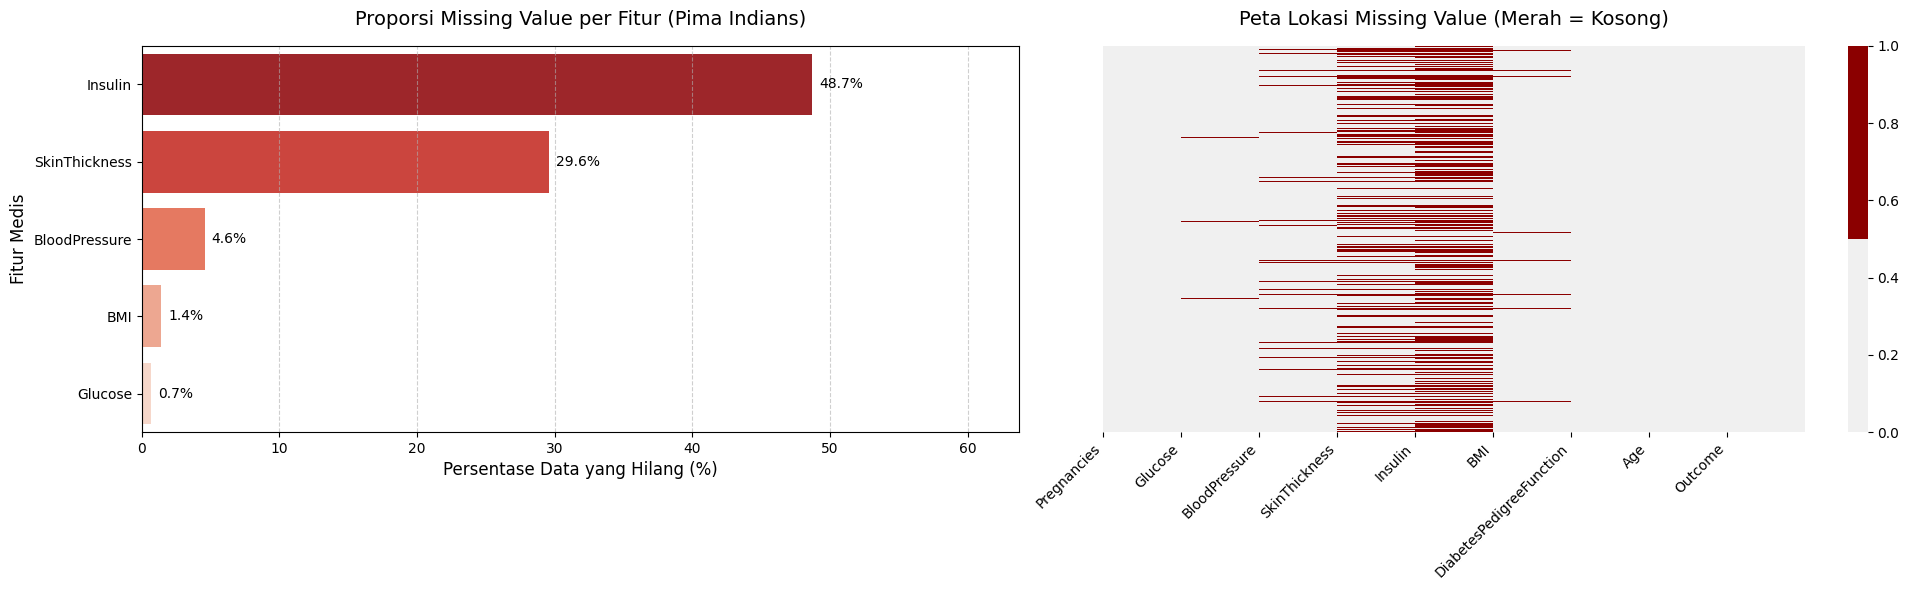

In [ ]:
# ==========================
# VISUALISASI MISSING VALUE
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Menghitung statistik missing value
mv_count = df.isnull().sum()
mv_percent = (mv_count / len(df)) * 100
mv_df = pd.DataFrame({'Fitur': mv_count.index, 'Jumlah': mv_count.values, 'Persentase': mv_percent.values})
mv_df = mv_df[mv_df['Jumlah'] > 0].sort_values(by='Persentase', ascending=False)

# --- Visualisasi A: Bar Chart Persentase dan Visualisasi B: Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# Subplot 1: Bar Chart Persentase
ax = sns.barplot(x='Persentase', y='Fitur', data=mv_df, palette='Reds_r', ax=axes[0])

for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=10)

axes[0].set_title('Proporsi Missing Value per Fitur (Pima Indians)', fontsize=14, pad=15)
axes[0].set_xlabel('Persentase Data yang Hilang (%)', fontsize=12)
axes[0].set_ylabel('Fitur Medis', fontsize=12)
axes[0].set_xlim(0, max(mv_df['Persentase']) + 15)
axes[0].grid(axis='x', linestyle='--', alpha=0.6)

# Subplot 2: Heatmap
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap=['#f0f0f0', '#8b0000'], ax=axes[1])
axes[1].set_title('Peta Lokasi Missing Value (Merah = Kosong)', fontsize=14, pad=15)
axes[1].set_xticks(ticks=np.arange(len(df.columns)), labels=df.columns, rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Bab 4. Hasil dan Pembahasan

## 4.1 Eksplorasi Data (EDA)

### 4.1.1 Gambaran Umum Dataset

In [ ]:
import pandas as pd

# URL dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Nama kolom sesuai dataset
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]

# Load dataset
df = pd.read_csv(url, names=columns)

# Info dasar
print(f"Dataset terdiri dari {df.shape[0]} baris dan {df.shape[1]} kolom")

print("\n5 Data Teratas:")
print(df.head())

print("\nStatistik Deskriptif:")
print(df.describe())

Dataset terdiri dari 768 baris dan 9 kolom

5 Data Teratas:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Statistik Deskriptif:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.79

### 4.1.2 Distribusi Fitur

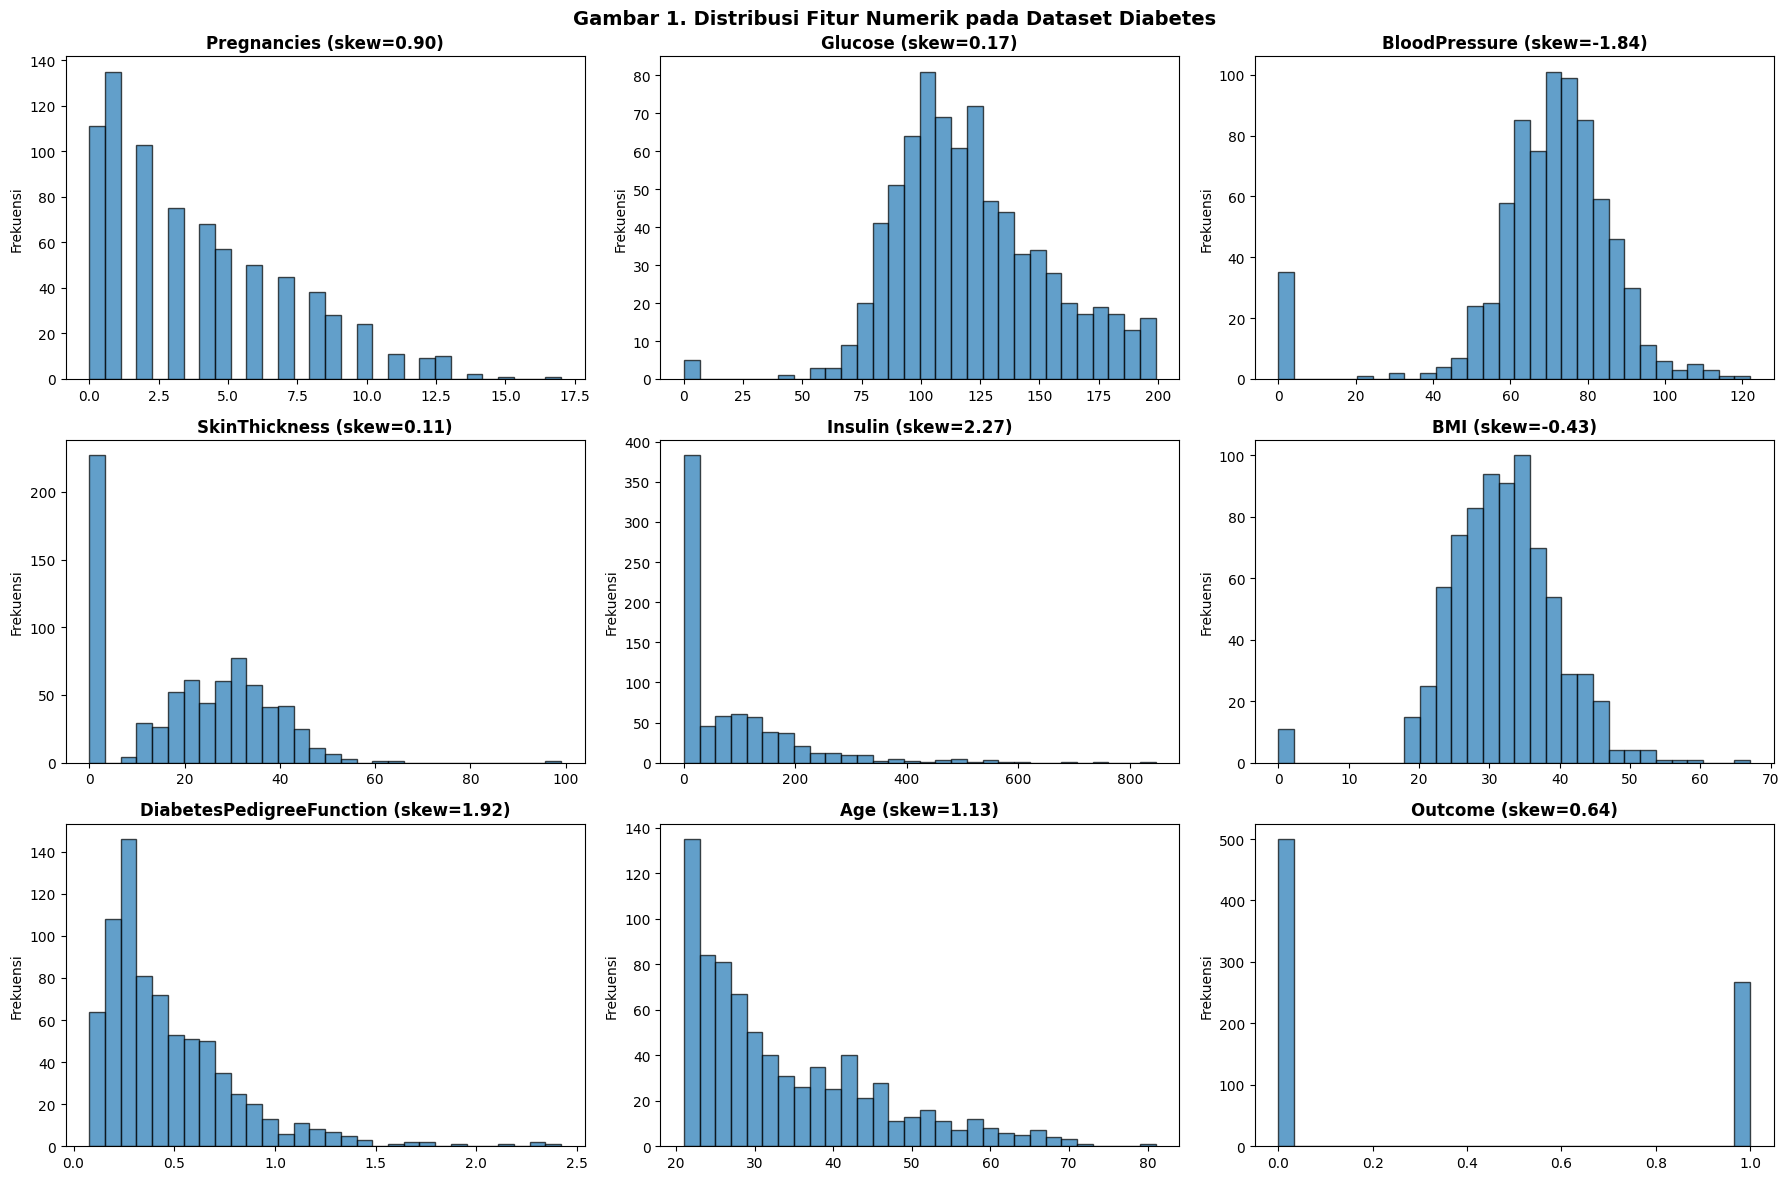

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# CEK KOLOM NUMERIK
# ==============================
num_cols = df.select_dtypes(include=[np.number]).columns

# =========================
# VISUALISASI DISTRIBUSI
# =========================
fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
    axes[i].set_title(f'{col} (skew={df[col].skew():.2f})', fontweight='bold')
    axes[i].set_ylabel('Frekuensi')

for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Gambar 1. Distribusi Fitur Numerik pada Dataset Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.1.3 Distribusi Kelas Target

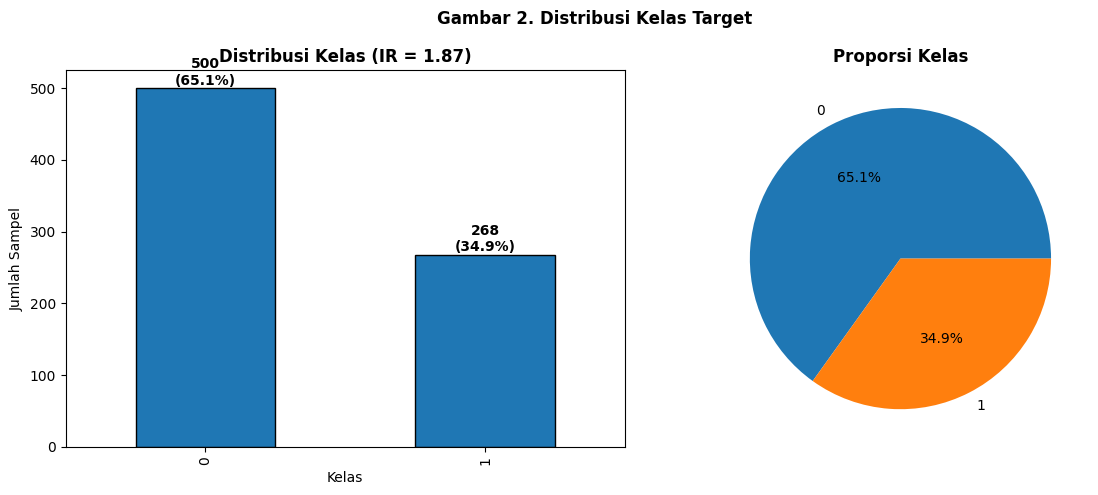

In [ ]:
import matplotlib.pyplot as plt

# ==============================
# KOLOM TARGET
# ==============================
target_col = 'Outcome'

# Hitung distribusi kelas
class_counts = df[target_col].value_counts()

# Imbalance Ratio (IR)
ir = class_counts.max() / class_counts.min()

# ==============================
# VISUALISASI
# ==============================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
class_counts.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title(f'Distribusi Kelas (IR = {ir:.2f})', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_xlabel('Kelas')

for i, v in enumerate(class_counts):
    axes[0].text(i, v + 5, f'{v}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%')
axes[1].set_title('Proporsi Kelas', fontweight='bold')

plt.suptitle('Gambar 2. Distribusi Kelas Target', fontweight='bold')
plt.tight_layout()
plt.show()

## 4.2 EDA Spesifikasi Topik

### 4.2.1 Visualisasi Pola Missing

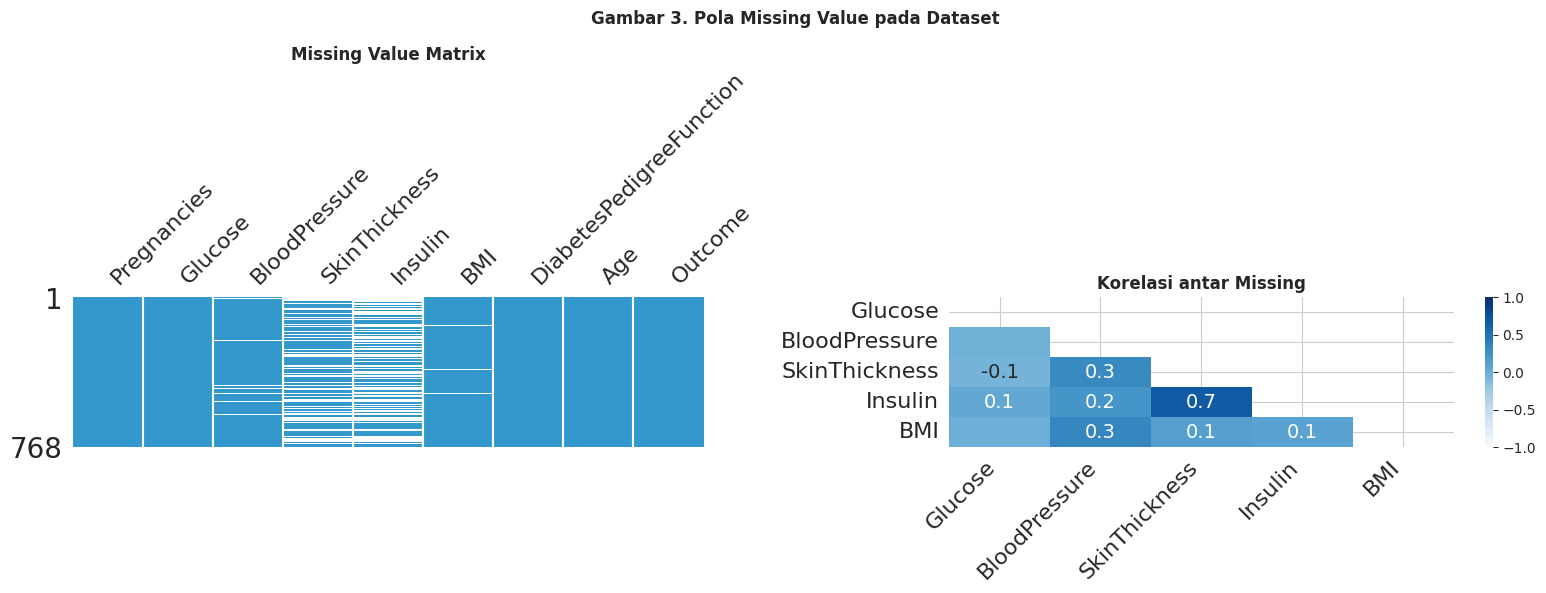

In [ ]:
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns

# Copy data
df_missing = df.copy()

cols_with_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_missing[cols_with_zero] = df_missing[cols_with_zero].replace(0, np.nan)

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

msno.matrix(
    df_missing,
    ax=axes[0],
    sparkline=False,
    color=(0.2, 0.6, 0.8)
)
axes[0].set_title('Missing Value Matrix', fontweight='bold')

# Heatmap
msno.heatmap(
    df_missing,
    ax=axes[1],
    cmap='Blues'
)
axes[1].set_title('Korelasi antar Missing', fontweight='bold')

plt.suptitle('Gambar 3. Pola Missing Value pada Dataset', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.3.1 Implementasi Imputasi (Minimal 3 Metode)

In [ ]:
import numpy as np
import pandas as pd # Added pandas import
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# ==============================
# LOAD DATA
# ==============================
# Link dataset Pima Indians Diabetes (Raw GitHub)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"

# Nama-nama kolom sesuai deskripsi dataset di Kaggle
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load data langsung dari URL
df = pd.read_csv(url, names=column_names)

# ==============================
# PREPROCESSING (0 → NaN)
# ==============================
df_model = df.copy()

cols_with_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df_model[cols_with_zeros] = df_model[cols_with_zeros].replace(0, np.nan)

# ==============================
# SPLIT DATA
# ==============================
X = df_model.drop("Outcome", axis=1)
y = df_model["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================
# BASELINE (tanpa imputasi)
# ==============================
# Drop missing value
X_train_base = X_train.dropna()
y_train_base = y_train[X_train_base.index]

X_test_base = X_test.dropna()
y_test_base = y_test[X_test_base.index]

# ==============================
# MEAN IMPUTATION
# ==============================
imp_mean = SimpleImputer(strategy='mean')
X_train_mean = imp_mean.fit_transform(X_train)
X_test_mean = imp_mean.transform(X_test)

# ==============================
# KNN IMPUTATION
# ==============================
imp_knn = KNNImputer(n_neighbors=5)
X_train_knn = imp_knn.fit_transform(X_train)
X_test_knn = imp_knn.transform(X_test)

# ==============================
# MICE / ITERATIVE IMPUTATION
# ==============================
imp_mice = IterativeImputer(max_iter=20, random_state=42)
X_train_mice = imp_mice.fit_transform(X_train)
X_test_mice = imp_mice.transform(X_test)

Visualisasi Before vs After

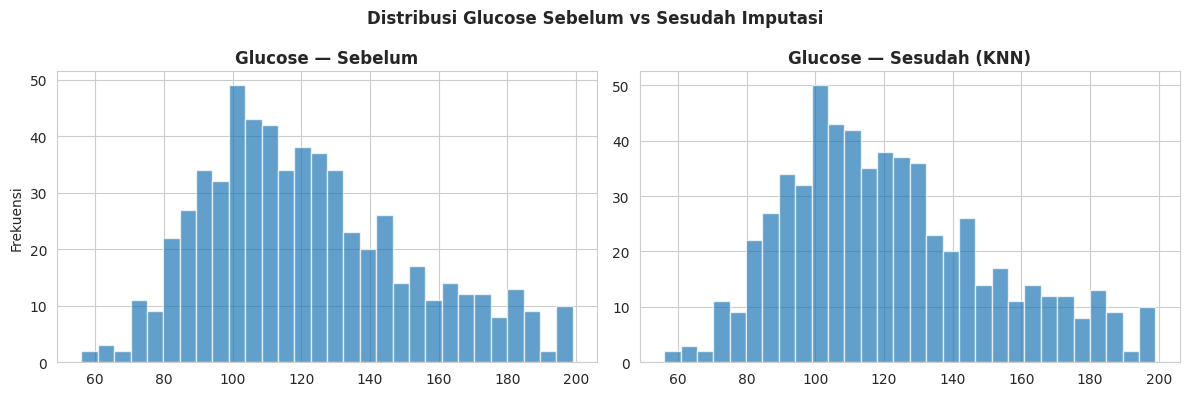

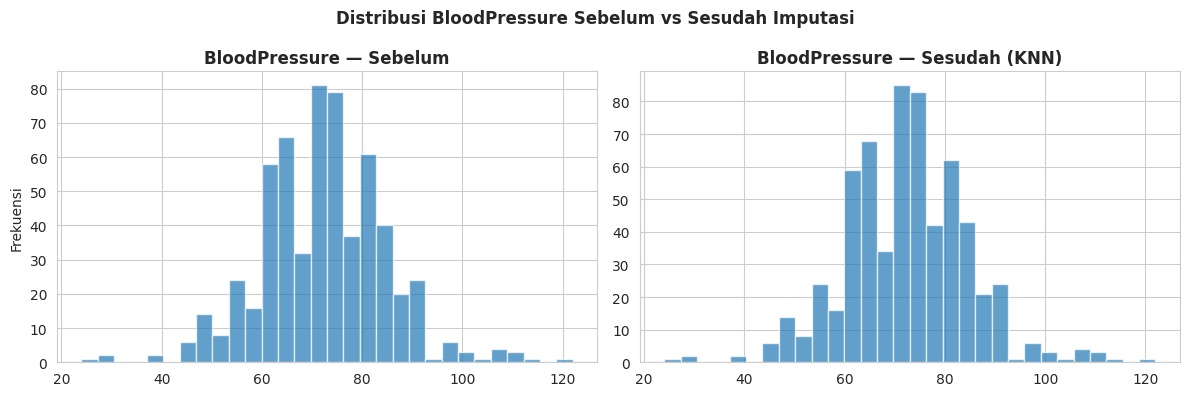

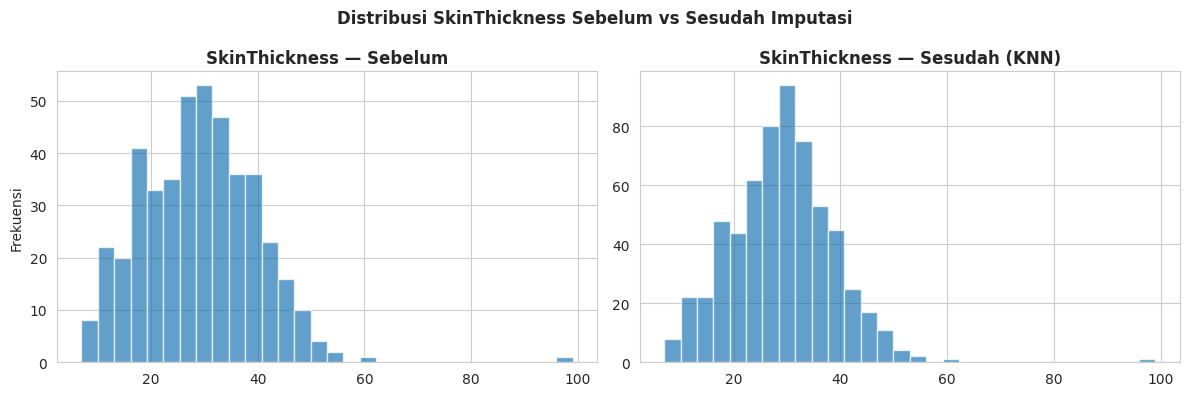

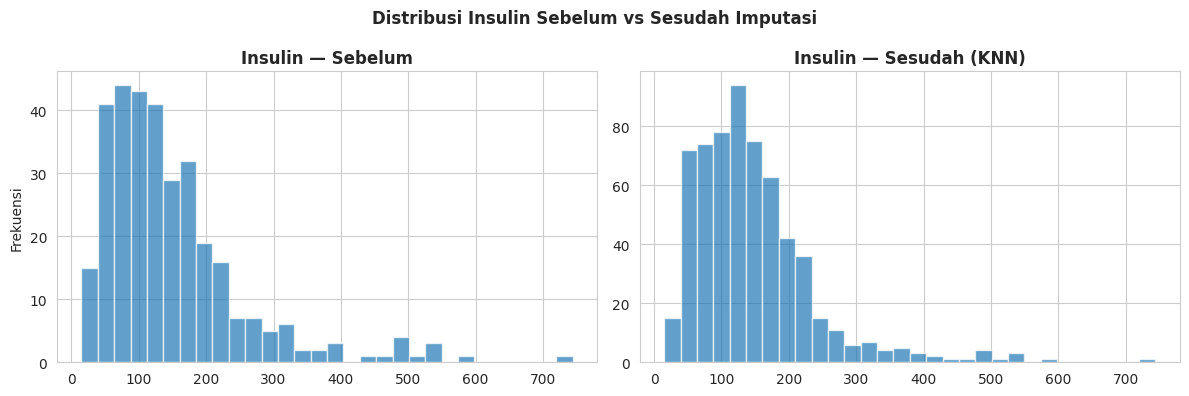

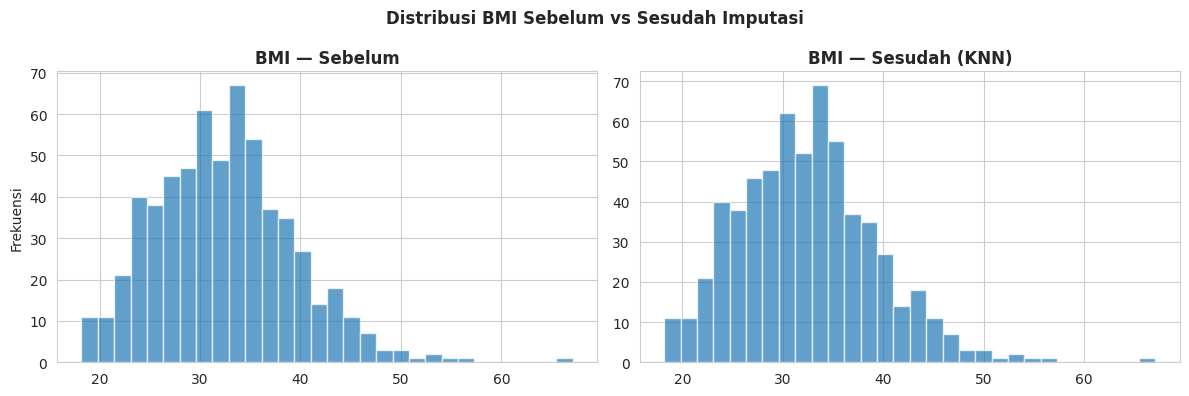

In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom yang memang ada missing
cols_missing = X_train.columns[X_train.isnull().any()].tolist()

for col in cols_missing:
    idx = X_train.columns.get_loc(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sebelum imputasi
    axes[0].hist(X_train[col].dropna(), bins=30, alpha=0.7)
    axes[0].set_title(f'{col} — Sebelum', fontweight='bold')
    axes[0].set_ylabel('Frekuensi')

    # Sesudah imputasi (KNN)
    axes[1].hist(X_train_knn[:, idx], bins=30, alpha=0.7)
    axes[1].set_title(f'{col} — Sesudah (KNN)', fontweight='bold')

    plt.suptitle(f'Distribusi {col} Sebelum vs Sesudah Imputasi', fontweight='bold')
    plt.tight_layout()
    plt.show()


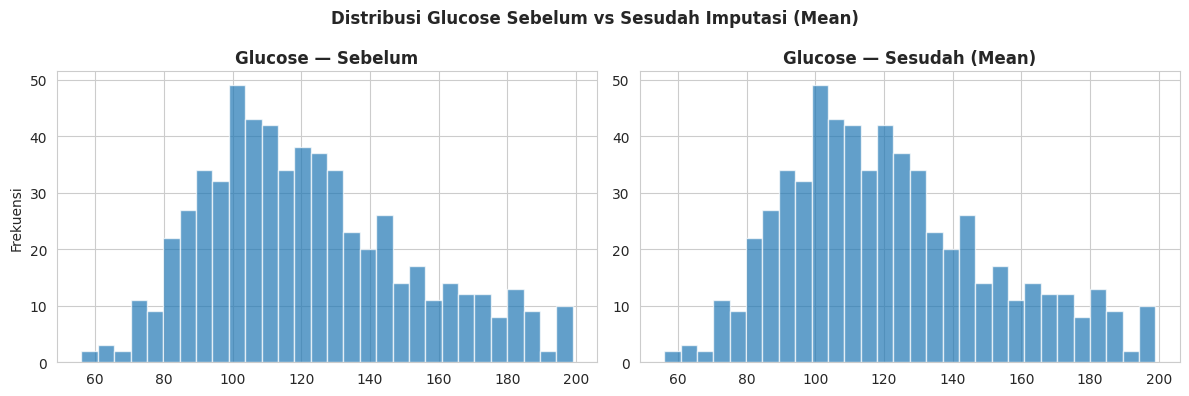

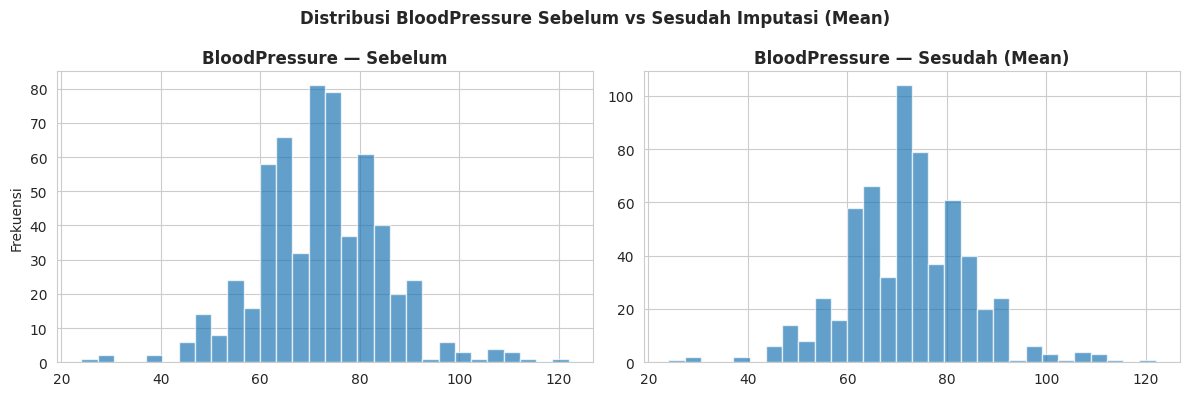

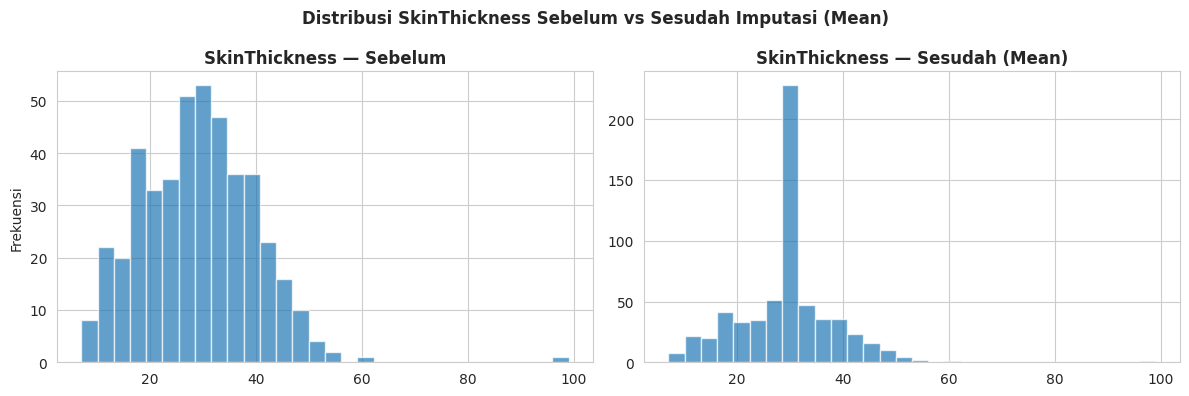

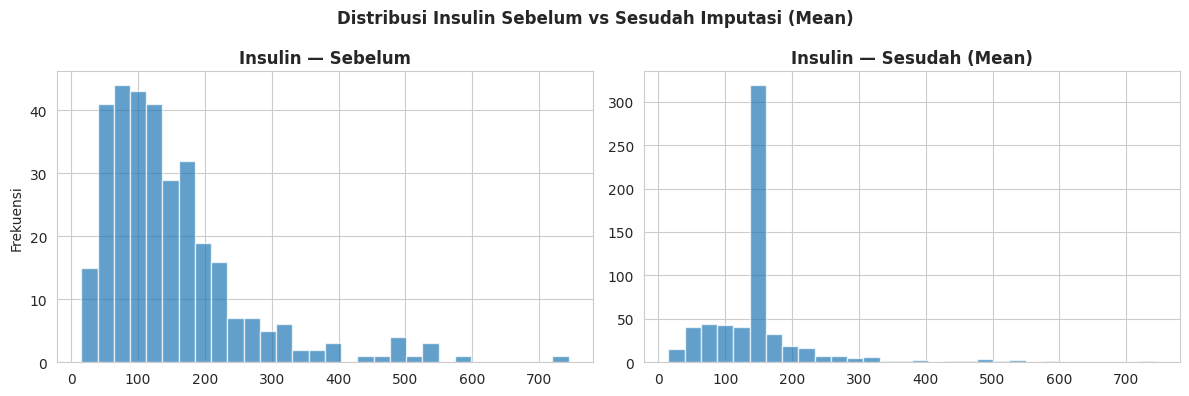

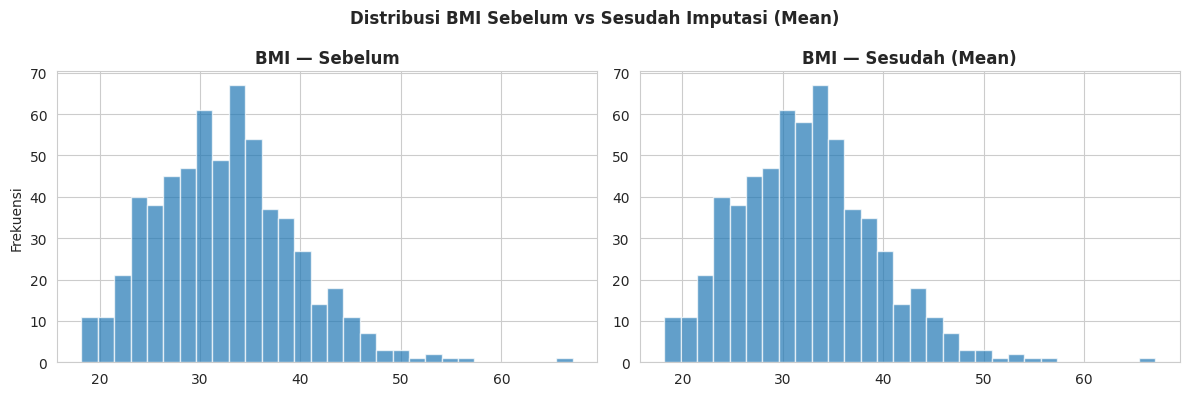

In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom yang memang ada missing
cols_missing = X_train.columns[X_train.isnull().any()].tolist()

for col in cols_missing:
    idx = X_train.columns.get_loc(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sebelum imputasi
    axes[0].hist(X_train[col].dropna(), bins=30, alpha=0.7)
    axes[0].set_title(f'{col} — Sebelum', fontweight='bold')
    axes[0].set_ylabel('Frekuensi')

    # Sesudah imputasi (Mean)
    axes[1].hist(X_train_mean[:, idx], bins=30, alpha=0.7)
    axes[1].set_title(f'{col} — Sesudah (Mean)', fontweight='bold')

    plt.suptitle(f'Distribusi {col} Sebelum vs Sesudah Imputasi (Mean)', fontweight='bold')
    plt.tight_layout()
    plt.show()

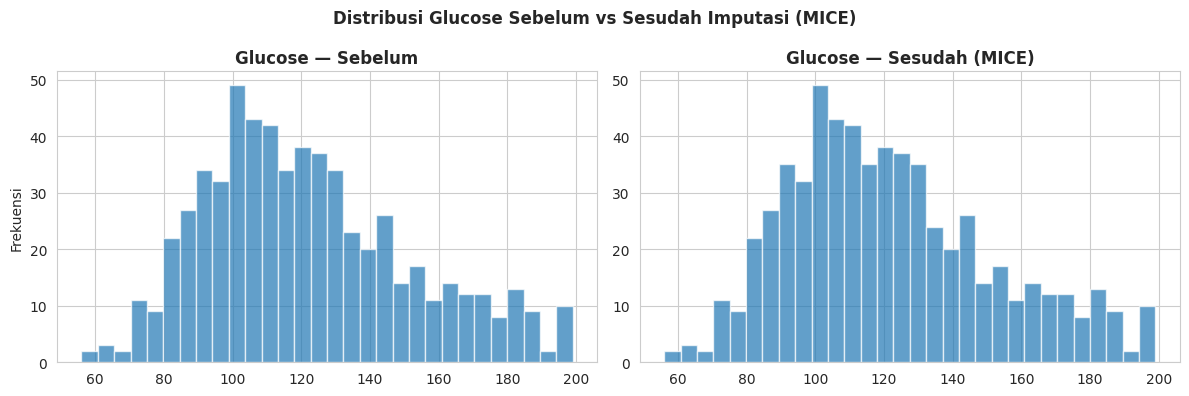

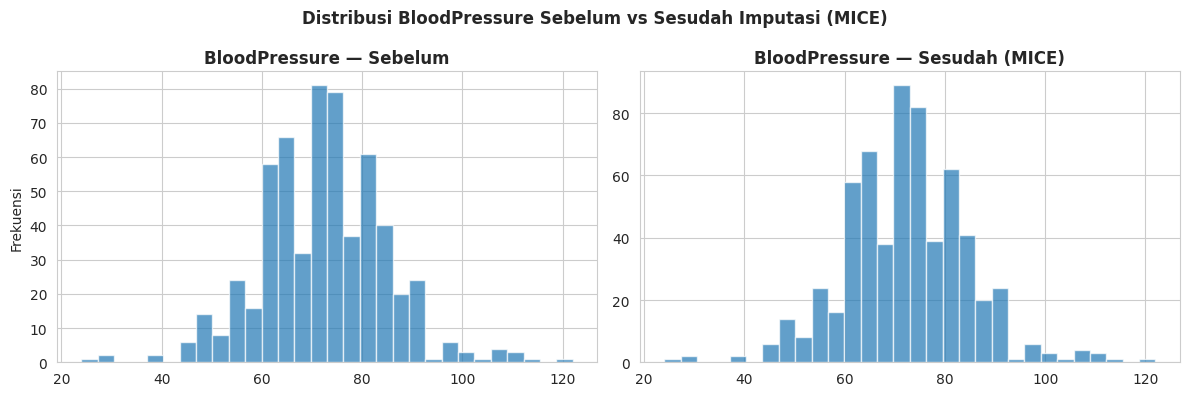

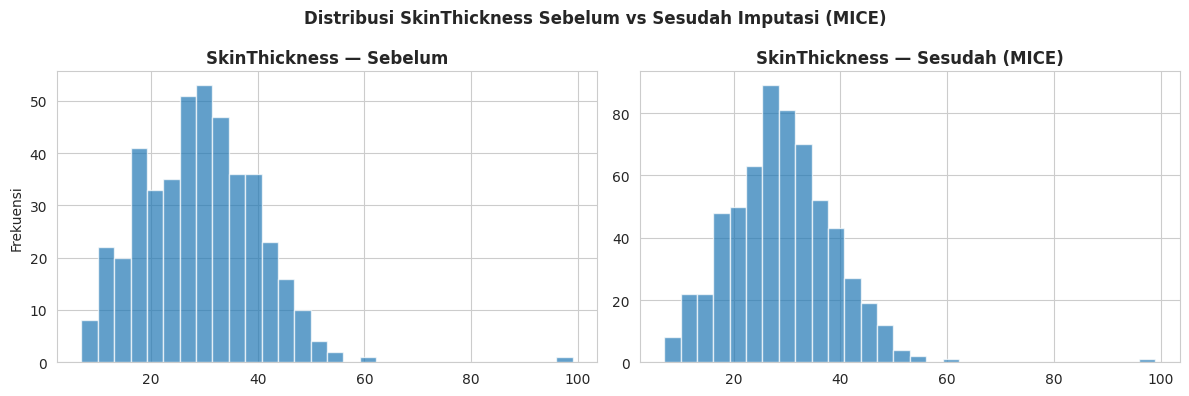

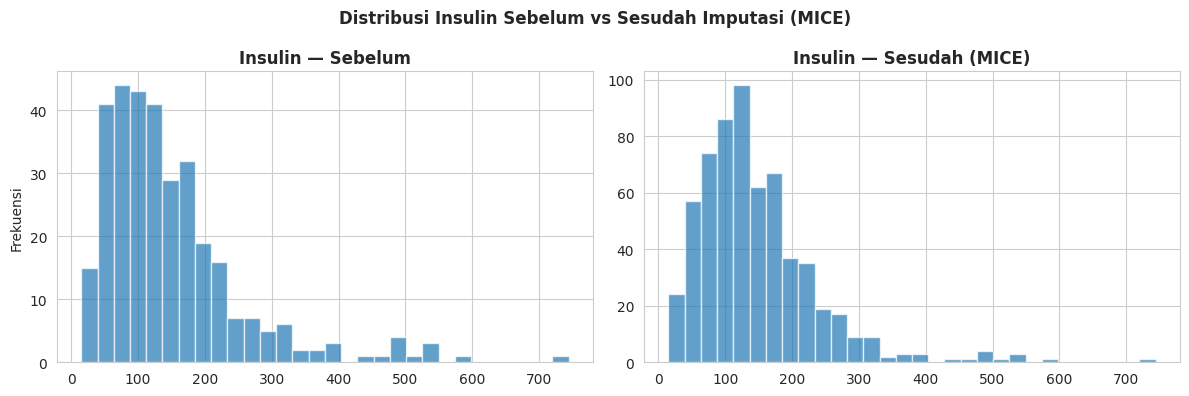

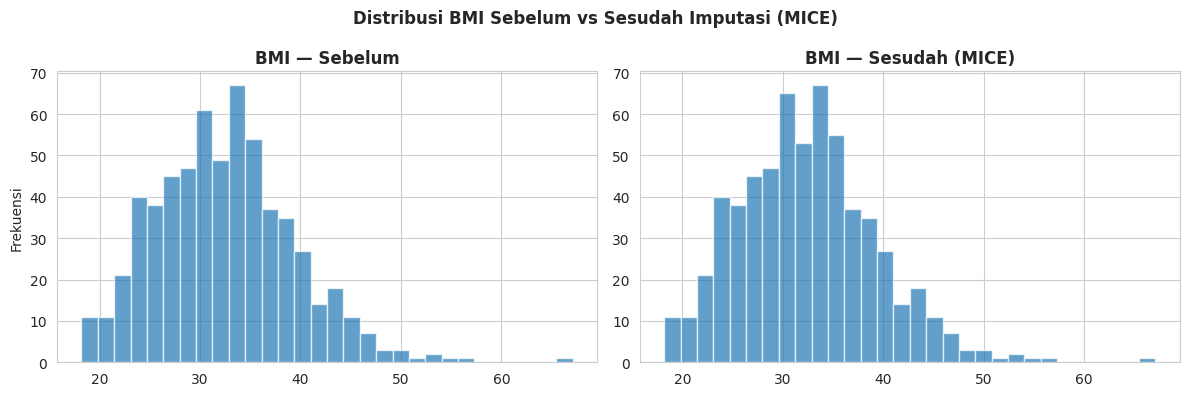

In [ ]:
import matplotlib.pyplot as plt

# Ambil kolom yang memang ada missing
cols_missing = X_train.columns[X_train.isnull().any()].tolist()

for col in cols_missing:
    idx = X_train.columns.get_loc(col)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Sebelum imputasi
    axes[0].hist(X_train[col].dropna(), bins=30, alpha=0.7)
    axes[0].set_title(f'{col} — Sebelum', fontweight='bold')
    axes[0].set_ylabel('Frekuensi')

    # Sesudah imputasi (MICE)
    axes[1].hist(X_train_mice[:, idx], bins=30, alpha=0.7)
    axes[1].set_title(f'{col} — Sesudah (MICE)', fontweight='bold')

    plt.suptitle(f'Distribusi {col} Sebelum vs Sesudah Imputasi (MICE)', fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

# ==============================
# FUNGSI EVALUASI
# ==============================
def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    result = {
        "Metode": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }
    return result

# ==============================
# DATA IMPUTASI (TRAIN & TEST)
# ==============================
imputations = {
    'Baseline (drop NA)': (
        X_train_base, y_train_base,
        X_test_base, y_test_base
    ),
    'Mean': (
        pd.DataFrame(X_train_mean, columns=X_train.columns), y_train,
        pd.DataFrame(X_test_mean, columns=X_test.columns), y_test
    ),
    'KNN (k=5)': (
        pd.DataFrame(X_train_knn, columns=X_train.columns), y_train,
        pd.DataFrame(X_test_knn, columns=X_test.columns), y_test
    ),
    'MICE': (
        pd.DataFrame(X_train_mice, columns=X_train.columns), y_train,
        pd.DataFrame(X_test_mice, columns=X_test.columns), y_test
    )
}

# ==============================
# LOOP EVALUASI DAN SIMPAN MODEL
# ==============================
all_results = []
trained_models = {}

for name, (X_tr, y_tr, X_te, y_te) in imputations.items():
    scaler = StandardScaler()

    X_tr_sc = scaler.fit_transform(X_tr)
    X_te_sc = scaler.transform(X_te)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr_sc, y_tr)
    trained_models[name] = model

    result = evaluate_model(model, X_te_sc, y_te, name)
    all_results.append(result)

# ==============================
# HASIL
# ==============================
df_compare = pd.DataFrame(all_results)
print(df_compare.to_string(index=False))


            Metode  Accuracy   Recall  F1-Score
Baseline (drop NA)  0.742857 0.571429  0.571429
              Mean  0.785714 0.629630  0.673267
         KNN (k=5)  0.733766 0.555556  0.594059
              MICE  0.753247 0.592593  0.627451


## 4.4 Hasil Perbandingan Metode

### 4.4.1 Tabel Perbandingan Performa

In [ ]:
from sklearn.metrics import accuracy_score, recall_score, f1_score
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name="Model"):
    """Evaluasi lengkap satu model."""
    y_pred = model.predict(X_test)

    try:
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    except:
        auc = None

    return {
        'Metode': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }

def compare_methods(results_list):
    """Membuat tabel perbandingan."""
    return pd.DataFrame(results_list).round(4)

df_compare = pd.DataFrame(all_results)

# Urutkan dari yang terbaik
df_compare = df_compare.sort_values(by='F1-Score', ascending=False)

df_compare = df_compare.reset_index(drop=True)

df_compare

,Metode,Accuracy,Recall,F1-Score
0,Mean,0.785714,0.629630,0.673267
1,MICE,0.753247,0.592593,0.627451
2,KNN (k=5),0.733766,0.555556,0.594059
3,Baseline (drop NA),0.742857,0.571429,0.571429


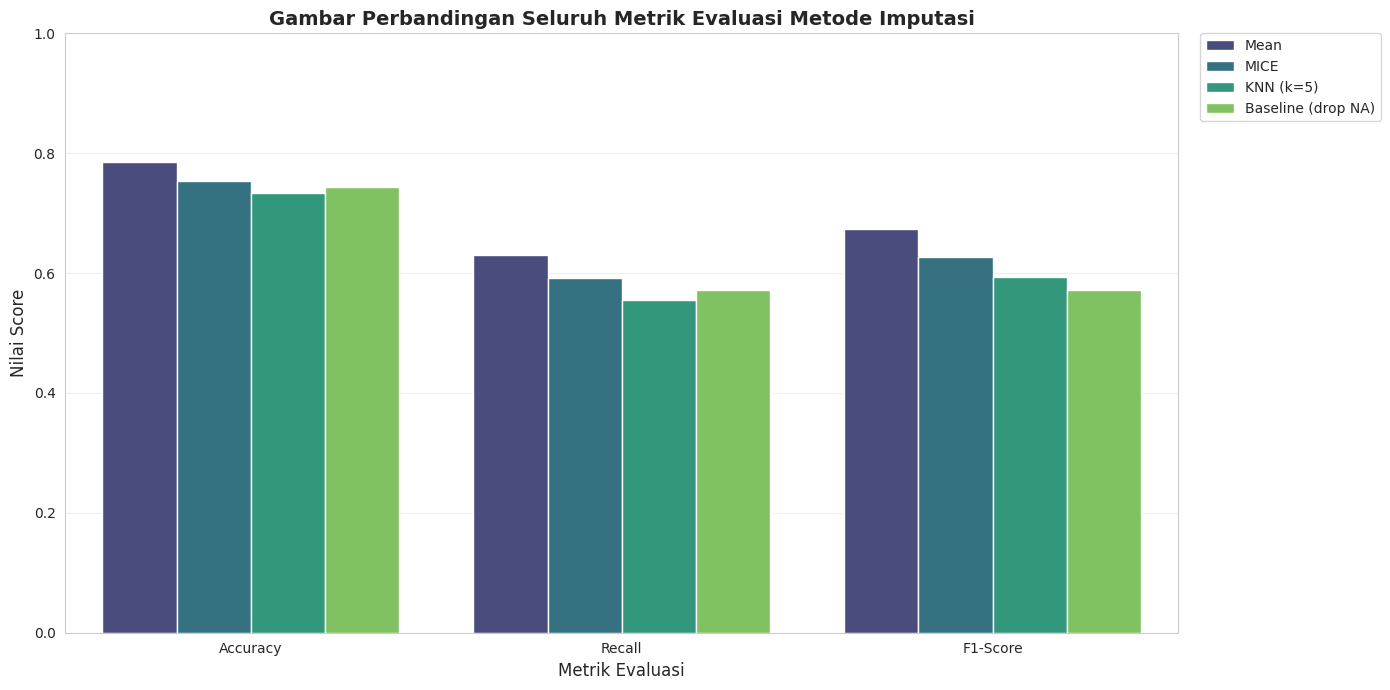

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Figure for Grouped Bar Chart
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# Prepare data
df_plot = df_compare.melt(id_vars='Metode', var_name='Metric', value_name='Score')

# Define the order of metrics
metric_order = ['Accuracy', 'Recall', 'F1-Score']
df_plot['Metric'] = pd.Categorical(df_plot['Metric'], categories=metric_order, ordered=True)

# Filter out 'Metode'
df_plot = df_plot[df_plot['Metric'].isin(metric_order)]

# Visualisasi Grouped Bar Chart (Semua Metrik)
sns.barplot(data=df_plot, x='Metric', y='Score', hue='Metode', palette='viridis', ax=ax)
ax.set_title('Gambar Perbandingan Seluruh Metrik Evaluasi Metode Imputasi',
   fontsize=14, fontweight='bold')
ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Nilai Score', fontsize=12)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

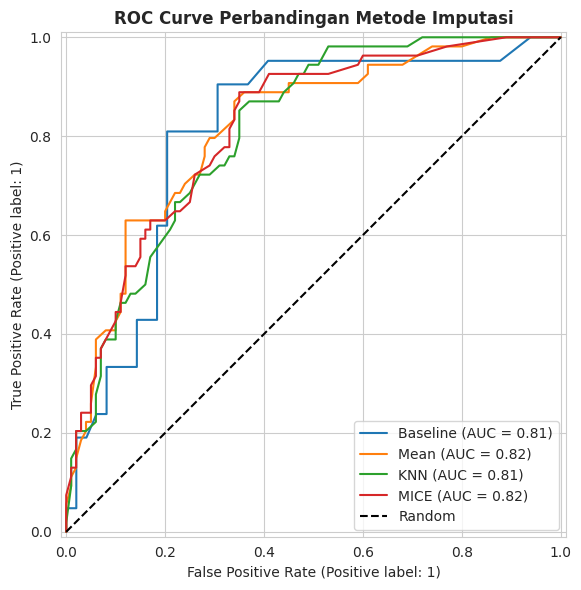

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

models_dict = {}

def train_and_store(name, X_train_data, y_train_data, X_test_data, y_test_data):
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train_data)
    X_te_sc = scaler.transform(X_test_data)

    model = RandomForestClassifier(random_state=42)
    model.fit(X_tr_sc, y_train_data)

    models_dict[name] = (model, X_te_sc, y_test_data)

# ==============================
# TRAIN SEMUA METODE
# ==============================

# Baseline
train_and_store("Baseline", X_train_base, y_train_base, X_test_base, y_test_base)

# Mean
train_and_store("Mean", pd.DataFrame(X_train_mean, columns=X_train.columns), y_train,
                pd.DataFrame(X_test_mean, columns=X_test.columns), y_test)

# KNN
train_and_store("KNN", pd.DataFrame(X_train_knn, columns=X_train.columns), y_train,
                pd.DataFrame(X_test_knn, columns=X_test.columns), y_test)

# MICE
train_and_store("MICE", pd.DataFrame(X_train_mice, columns=X_train.columns), y_train,
                pd.DataFrame(X_test_mice, columns=X_test.columns), y_test)

# ==============================
# ROC CURVE
# ==============================

fig, ax = plt.subplots(figsize=(8, 6))

for name, (model, X_te, y_te) in models_dict.items():
    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', label='Random')

ax.set_title('ROC Curve Perbandingan Metode Imputasi', fontweight='bold')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()

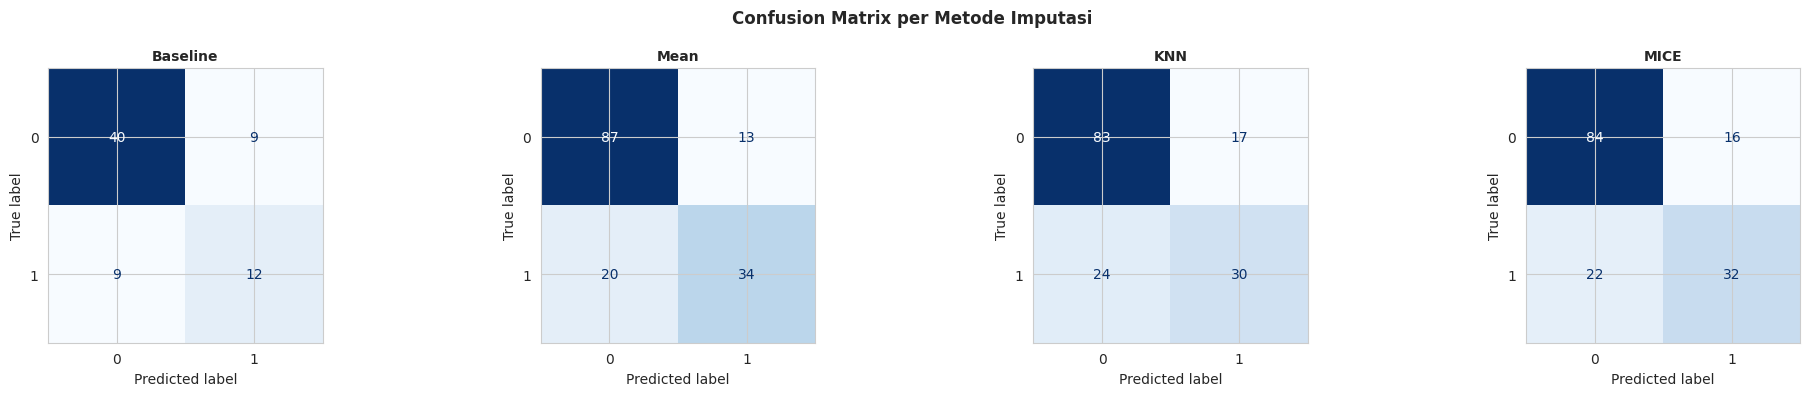

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(models_dict), figsize=(5*len(models_dict), 4))

if len(models_dict) == 1:
    axes = [axes]

for i, (name, (model, X_te, y_te)) in enumerate(models_dict.items()):
    ConfusionMatrixDisplay.from_estimator(
        model,
        X_te,
        y_te,
        ax=axes[i],
        cmap='Blues',
        colorbar=False
    )
    axes[i].set_title(name, fontweight='bold', fontsize=10)

plt.suptitle('Confusion Matrix per Metode Imputasi', fontweight='bold')
plt.tight_layout()
plt.show()